1. **Cite 5 diferenças entre o Random Forest e o AdaBoost**
2. **Acesse o link Scikit-learn - adaboost, leia a explicação (traduza se for preciso) e crie um jupyter notebook contendo o exemplo do AdaBoost**
3. **Cite 5 Hiperparâmetros importantes no AdaBoost**
4. **(Opcional) Utilize o GridSearch para encontrar os melhores hiperparâmetros para o conjunto de dados do exemplo (load_iris)**

---

### **1**

- O AdaBoost se diferencia significativamente na lógica de pesos, atribuindo a cada árvore um poder de decisão proporcional ao seu desempenho.
- Enquanto a primeira *stump* (modelo de árvore utilizado no AdaBoost) é construída de forma independente, todas as árvores seguintes têm seus pesos ajustados com base nos erros da árvore anterior, estabelecendo uma relação de hierarquia e dependência.
- Diferentemente do Random Forest, que desenvolve uma floresta de árvores completas, o AdaBoost trabalha com árvores totalmente podadas, com profundidade igual a 1 e duas folhas.
- O AdaBoost não possui o hiperparâmetro `n_jobs` para processamento paralelo, justamente por causa da dependência sequencial entre as árvores.
- As predições no AdaBoost não são definidas por uma votação simples, como ocorre no Random Forest. Em vez disso, utiliza-se uma votação ponderada, onde o índice de performance de cada *stump* determina o peso do seu voto, sendo usado tanto na construção das árvores quanto na definição do resultado final.

---

### 2

In [43]:
# Importações para manipulação de dados
import pandas as pd  # Para manipulação de dados em DataFrames

# Importações para visualização de dados
import matplotlib.pyplot as plt  # Para criação de gráficos e visualizações

# Importações de datasets
from sklearn.datasets import load_iris, make_gaussian_quantiles, make_regression  # Para carregar datasets de exemplo

# Importações para manipulação e avaliação de modelos
from sklearn.model_selection import cross_val_score, train_test_split  # Para validação cruzada e divisão de dados em treino/teste
from sklearn.metrics import accuracy_score  # Para calcular a acurácia do modelo

# Importações de modelos
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor  # Para os modelos AdaBoost (classificação e regressão)
from sklearn.tree import DecisionTreeClassifier  # Para criar árvores de decisão como weak learners
from sklearn.dummy import DummyClassifier  # Para criar modelos base simples (baseline)

In [35]:
# Carrega o conjunto de dados Iris e separa as features (X) e os rótulos (y)
X, y = load_iris(return_X_y=True)

# Cria um modelo AdaBoost com 100 estimadores e uma semente aleatória para reprodutibilidade
clf = AdaBoostClassifier(n_estimators=100, random_state=42)

# Realiza validação cruzada com 5 folds e calcula as acurácias para cada divisão
scores = cross_val_score(clf, X, y, cv=5)

# Calcula e retorna a média das acurácias obtidas na validação cruzada
scores.mean()

c:\Users\hfasa\anaconda3\envs\EBAC\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\hfasa\anaconda3\envs\EBAC\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\hfasa\anaconda3\envs\EBAC\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\hfasa\anaconda3\envs\EBAC\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent thi

0.9466666666666665

#### Multi-class AdaBoosted Decision Trees

In [36]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

In [37]:
# Gera um conjunto de dados sintético com distribuição gaussiana
# n_samples: número de amostras a serem geradas
# n_features: número de características (features) para cada amostra
# n_classes: número de classes para classificação
# random_state: semente aleatória para reprodutibilidade
X, y = make_gaussian_quantiles(n_samples=2000, n_features=10, n_classes=3, random_state=1)

In [38]:
# Divide o conjunto de dados em treino e teste
# X_train, X_test: características (features) para treino e teste
# y_train, y_test: rótulos (labels) para treino e teste
# random_state: semente aleatória para garantir reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=420)

In [39]:
# Define um weak learner (aprendiz fraco) como uma árvore de decisão com profundidade máxima de 1 e no máximo 8 folhas
weak_learner = DecisionTreeClassifier(max_depth=1, max_leaf_nodes=8)

# Define o número de estimadores (número de weak learners a serem usados no AdaBoost)
n_estimators = 100

# Cria e treina um modelo AdaBoost com o weak learner definido, número de estimadores e uma semente aleatória para reprodutibilidade
adaboost_clf = AdaBoostClassifier(
    estimator=weak_learner, n_estimators=n_estimators, random_state=42,
).fit(X_train, y_train)

c:\Users\hfasa\anaconda3\envs\EBAC\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [40]:
# Cria um modelo DummyClassifier que serve como baseline para comparação
dummy_clf = DummyClassifier()

# Define uma função para calcular o erro de classificação (1 - acurácia)
def misclassification_error(y_true, y_pred):
    return 1 - accuracy_score(y_true, y_pred)

# Calcula o erro de classificação do weak learner (árvore de decisão com profundidade máxima de 1)
weak_learner_missclassification_error = misclassification_error(
    y_test, weak_learner.fit(X_train, y_train).predict(X_test)
)

# Calcula o erro de classificação do DummyClassifier (modelo baseline)
dummy_classifiers_misclassification_error = misclassification_error(
    y_test, dummy_clf.fit(X_train, y_train).predict(X_test)
)

# Exibe o erro de classificação do weak learner
print(
    f"Missclassification error of the weak learner: {weak_learner_missclassification_error:.3f}"
)

# Exibe o erro de classificação do DummyClassifier
print(
    f"Missclassification error of the dummy classifier: {dummy_classifiers_misclassification_error:.3f}"
)

Missclassification error of the weak learner: 0.634
Missclassification error of the dummy classifier: 0.684


C:\Users\hfasa\AppData\Local\Temp\ipykernel_26864\350963597.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(
C:\Users\hfasa\AppData\Local\Temp\ipykernel_26864\350963597.py:30: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k:" (-> color='k'). The keyword argument will take precedence.
  plt.plot(


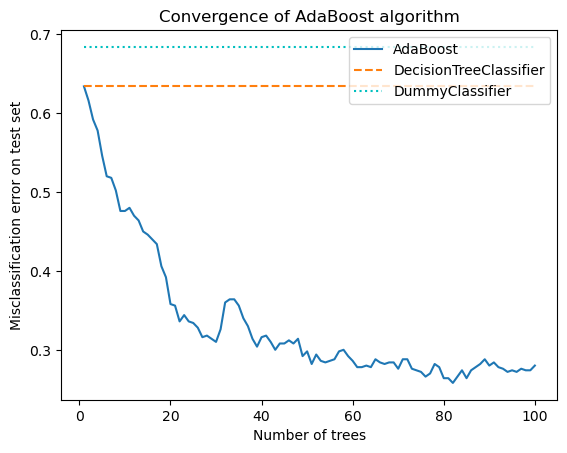

In [41]:
# Cria um DataFrame para armazenar os erros de classificação do AdaBoost
# "Number of trees": número de árvores (estimadores) no AdaBoost
# "AdaBoost": lista de erros de classificação calculados para cada estágio do AdaBoost
boosting_errors = pd.DataFrame(
    {
        "Number of trees": range(1, n_estimators + 1),  # Intervalo de 1 até o número total de estimadores
        "AdaBoost": [
            misclassification_error(y_test, y_pred)  # Calcula o erro de classificação para cada predição do AdaBoost
            for y_pred in adaboost_clf.staged_predict(X_test)  # Obtém as predições em cada estágio do AdaBoost
        ],
    }
).set_index("Number of trees")  # Define "Number of trees" como índice do DataFrame

# Plota os erros de classificação do AdaBoost ao longo do número de árvores
ax = boosting_errors.plot()
ax.set_ylabel("Misclassification error on test set")  # Define o rótulo do eixo Y
ax.set_xlabel("Number of trees")  # Define o rótulo do eixo X
ax.set_title("Convergence of AdaBoost algorithm")  # Define o título do gráfico

# Adiciona uma linha pontilhada para o erro de classificação do weak learner (árvore de decisão)
plt.plot(
    [boosting_errors.index.min(), boosting_errors.index.max()],  # Intervalo do eixo X
    [weak_learner_missclassification_error, weak_learner_missclassification_error],  # Erro constante do weak learner
    "k--",  # Estilo da linha (pontilhada)
    label="Weak learner",  # Rótulo da legenda
    color="tab:orange",  # Cor da linha
)

# Adiciona uma linha pontilhada para o erro de classificação do DummyClassifier (baseline)
plt.plot(
    [boosting_errors.index.min(), boosting_errors.index.max()],  # Intervalo do eixo X
    [dummy_classifiers_misclassification_error, dummy_classifiers_misclassification_error],  # Erro constante do DummyClassifier
    "k:",  # Estilo da linha (pontilhada com pontos)
    label="Dummy classifier",  # Rótulo da legenda
    color="c",  # Cor da linha
)

# Adiciona a legenda ao gráfico
plt.legend(["AdaBoost", "DecisionTreeClassifier", "DummyClassifier"], loc=1)

# Exibe o gráfico
plt.show()

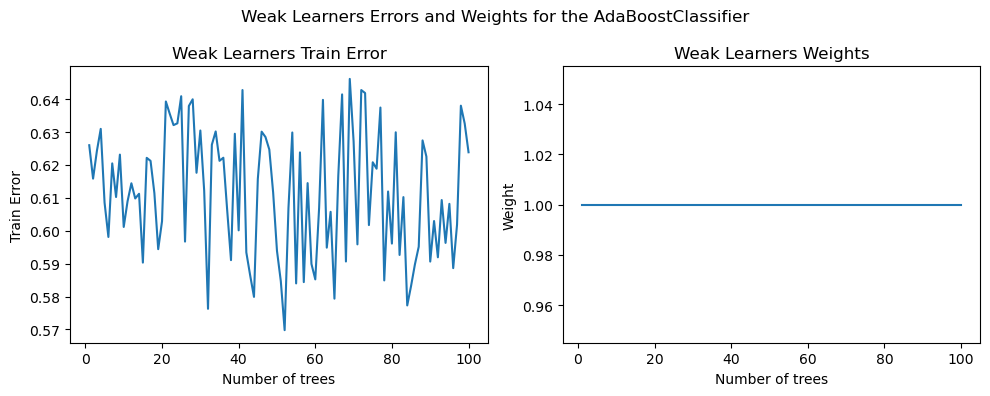

In [42]:
weak_learners_info = pd.DataFrame(
    {
        "Number of trees": range(1, n_estimators + 1),
        "Errors": adaboost_clf.estimator_errors_,  # Erros de cada weak learner
        "Weights": adaboost_clf.estimator_weights_,  # Pesos de cada weak learner
    }
).set_index("Number of trees")  # Define "Number of trees" como índice do DataFrame

axs = weak_learners_info.plot(
    subplots=True, layout=(1,2), figsize=(10, 4), legend=False, color="tab:blue")

axs[0,0].set_ylabel("Train Error")  # Define o rótulo do eixo Y para o primeiro gráfico
axs[0,0].set_title("Weak Learners Train Error")  # Define o título do primeiro gráfico
axs[0,1].set_ylabel("Weight")  # Define o rótulo do eixo Y para o segundo gráfico
axs[0,1].set_title("Weak Learners Weights")  # Define o título do segundo gráfico
fig = axs[0,0].get_figure()  # Obtém a figura do primeiro gráfico
fig.suptitle("Weak Learners Errors and Weights for the AdaBoostClassifier")  # Define o título geral da figura
fig.tight_layout()

#### AdaBoostRegressor

In [44]:
X, y = make_regression(
    n_features=4, n_informative=2, random_state=0, shuffle=False
)  # Gera um conjunto de dados sintético para regressão


regr = AdaBoostRegressor(
    n_estimators=100, random_state=0
)  # Cria um modelo AdaBoost para regressão
regr.fit(X, y)  # Treina o modelo com os dados de treino

AdaBoostRegressor(n_estimators=100, random_state=0)

### 3 

- **n_estimators** -> Define a quantidade máxima de iterações do processo de boosting. O processo pode ser interrompido antes caso o modelo alcance um ajuste perfeito aos dados.

- **learning_rate** -> Funciona como um regulador da modelagem, reduzindo os pesos atribuídos aos estimadores para evitar overfitting. Esse hiperparâmetro desempenha um papel crucial ao suavizar os ajustes, prevenindo discrepâncias e mudanças bruscas. Por outro lado, pode ser configurado para tornar o processo de modelagem mais agressivo, buscando um desempenho superior, mas com maior risco de overfitting.

- **estimator** -> Define o modelo base (weak learner) utilizado em cada iteração do boosting. No caso do AdaBoost, é comum utilizar árvores de decisão simples (stumps) como estimadores fracos, mas outros modelos podem ser configurados dependendo do problema e da necessidade.

- **random_state** -> Define uma semente para o gerador de números aleatórios, garantindo que os resultados sejam reprodutíveis. Isso é especialmente útil para comparar diferentes execuções do modelo, pois assegura que a divisão dos dados, a inicialização dos estimadores e outros processos aleatórios sejam consistentes entre as execuções.

- **algorithm** -> Define o tipo de algoritmo de boosting a ser utilizado. No AdaBoost, existem duas opções principais: `"SAMME"` (Stagewise Additive Modeling using a Multiclass Exponential loss function) e `"SAMME.R"` (SAMME com Real Boost). O `"SAMME.R"` é mais eficiente, pois utiliza as probabilidades previstas pelos estimadores fracos para ajustar os pesos, enquanto o `"SAMME"` utiliza apenas as predições discretas. O `"SAMME.R"` é o padrão para problemas de classificação.

### 4

In [53]:
# Carrega o conjunto de dados Iris e separa as features (X) e os rótulos (y)
X, y = load_iris(return_X_y=True)

# Cria um modelo AdaBoost com 100 estimadores e uma semente aleatória para reprodutibilidade
clf = AdaBoostClassifier(n_estimators=100, random_state=42)

# Calcula e retorna a média das acurácias obtidas na validação cruzada
scores.mean()

0.9466666666666665

In [54]:
from sklearn.model_selection import GridSearchCV  # Para busca em grade de hiperparâmetros

params = {"n_estimators": [50, 100, 200], 
          "learning_rate": [0.01, 0.1, 1]}

grid_adaboost = GridSearchCV(estimator= AdaBoostClassifier(), 
                             param_grid=params, 
                             scoring="accuracy", 
                             cv=5, 
                             )

grid_adaboost.fit(X, y)  # Treina o modelo com os dados de treino

c:\Users\hfasa\anaconda3\envs\EBAC\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\hfasa\anaconda3\envs\EBAC\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\hfasa\anaconda3\envs\EBAC\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\hfasa\anaconda3\envs\EBAC\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent thi

GridSearchCV(cv=5, estimator=AdaBoostClassifier(),
             param_grid={'learning_rate': [0.01, 0.1, 1],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [58]:
print(grid_adaboost.best_params_ ) # Exibe os melhores hiperparâmetros encontrados pela busca em grade
print(grid_adaboost.best_score_ ) # Exibe a melhor acurácia obtida com os melhores hiperparâmetros

{'learning_rate': 0.1, 'n_estimators': 200}
0.9466666666666667
